# Constructive Heuristic for the Traveling Salesman Problem
Dra. Salazar

Selected Topics of Optimization

---



## 1. Team: 3
|Student ID      | Name                           | Email               |
|----------------|--------------------------------|---------------------|
|----------------|--------------------------------|---------------------|
|----------------|--------------------------------|---------------------|
|----------------|--------------------------------|---------------------|


## 2. General Description of the Problem
The combinatorial problem being studied is the Travelling Salesman Problem (TSP); it consists of finding the shortest route that a travelling salesman can take if he needs to visit each city from a list of cities, exactly once and then returning to the starting city.

The TSP belongs to the NP-Complete type of problem,  meaning that if one can find an efficient algorithm for the TSP, then efficient algorithms could be found for all other problems in the NP-complete class.

Problems having the TSP structure occur in the analysis of the structure of crystals, in the overhauling of gas turbine engines, in the sequencing of jobs on a single machine.

## 3. Mathematical Formulation
Letting $x$ be the decision variable, $c$ the cost of the route, $m$ the total cities to visit, and $K$ is any group of cities that is not empty and does not include all the cities.

\begin{align}
\text{Minimize} \quad & \sum_{i=1}^{m} \sum_{j=1}^{m} c_{ij} x_{ij} \\
\text{Subject to:} \quad
& \sum_{j=1}^{m} x_{ij} = 1 && \forall i = 1,\dots,m \\
& \sum_{i=1}^{m} x_{ij} = 1 && \forall j = 1,\dots,m \\
& \sum_{i \in K} \sum_{j \in K} x_{ij} \le |K| - 1
&& \forall K \subset \{1,\dots,m\},\; K \neq \emptyset \\
& x_{ij} \in \{0,1\} && \forall i,j
\end{align}

## 4. Pseudocode of the Proposed Constructive Heuristic (BEST INSERTION)



```
Input: [A set of nodes with geographical coordinates (Latitude, Longitude)]
Initialize the tour with the first two nodes from the dataset: [Node1, Node2, Node1]
  Evaluate all existing edges (i, j) in the current tour.
  Calculate the incremental cost of inserting 'u' between 'i' and 'j' using the formula:
  Cost = Distance (i,u) + Distance (u,j) - Distance (i,j) .
  Select the insertion position that results in the minimum incremental cost.
  Insert node 'u' into that best position.
Repeat the same process until all nodes from the dataset are used or part of the tour.
Output: [A complete tour visiting all the nodes once and returning to the origin, along with its total distance]
```

## 5. Description and Definition of Main Functions



- `calculate_distance(node1,node2)`: Computes the distance between two points using the Haversine formula.
- `load_data(file_path`: Uses the Pandas library to read CSV files and extract IDs and coordinates into a dictionary format.
- `construct_solution_nn(data)`: Implements the Nearest Neighbor heuristic as a baseline.
- `construct_solution(data)`: Our proposed heuristic based on Best Insertion.
- `evaluate_solution(solution)`: Sums the distances and obtain the objective function value.
- `visualize_solution(solution)`: Generates a plot using Matplotlib.
- `check_feasibility(solution, original_data)`: Validates that the solution is valid as a TSP tour.



In [ ]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
import os

def calculate_distance(node1, node2):
    R = 6371.0
    lat1, lon1 = math.radians(node1['x']), math.radians(node1['y'])
    lat2, lon2 = math.radians(node2['x']), math.radians(node2['y'])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat / 2.0)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2.0)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

def load_data(file_path):
    try:
        df = pd.read_csv(file_path, encoding='latin-1')
        nodes = []
        for _, row in df.dropna().iterrows():
            nodes.append({
                'id': str(row.iloc[0]),
                'x': float(row.iloc[1]),
                'y': float(row.iloc[2])
            })
        return nodes
    except Exception as e:
        print(f"Error: Could not read file '{file_path}'. {e}")
        return []

def construct_solution_nn(nodes_list):
    if len(nodes_list) < 2: return nodes_list
    unvisited = nodes_list[1:].copy()
    tour = [nodes_list[0]]
    current = nodes_list[0]
    while unvisited:
        best_dist = float('inf')
        best_idx = -1
        for i, candidate in enumerate(unvisited):
            dist = calculate_distance(current, candidate)
            if dist < best_dist:
                best_dist, best_idx = dist, i
        current = unvisited.pop(best_idx)
        tour.append(current)
    tour.append(tour[0])
    return tour

def construct_solution(nodes_list):
    if len(nodes_list) < 2: return nodes_list
    tour = [nodes_list[0], nodes_list[1], nodes_list[0]]
    unvisited = nodes_list[2:].copy()
    while unvisited:
        best_cost = float('inf')
        best_node_idx = -1
        best_insert_pos = -1
        for u_idx, u_node in enumerate(unvisited):
            for i in range(len(tour) - 1):
                cost = calculate_distance(tour[i], u_node) + \
                       calculate_distance(u_node, tour[i+1]) - \
                       calculate_distance(tour[i], tour[i+1])
                if cost < best_cost:
                    best_cost, best_node_idx, best_insert_pos = cost, u_idx, i + 1
        tour.insert(best_insert_pos, unvisited.pop(best_node_idx))
    return tour

def evaluate_solution(solution):
    return sum(calculate_distance(solution[i], solution[i+1]) for i in range(len(solution)-1))

def visualize_solution(solution, title):
    if not solution:
        return

    x_coords = [node['y'] for node in solution]
    y_coords = [node['x'] for node in solution]
    ids = [node['id'] for node in solution]

    plt.figure(figsize=(10, 6))
    plt.plot(x_coords, y_coords, marker='o', linestyle='-', color='teal', markersize=8)
    plt.plot(x_coords[0], y_coords[0], marker='s', color='red', markersize=10, label='Start/End')

    for i, (x, y, node_id) in enumerate(zip(x_coords[:-1], y_coords[:-1], ids[:-1])):
        plt.annotate(node_id, (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

def check_feasibility(solution, original_data):
    if not solution or not original_data:
        return False, "Empty solution or data."

    if len(solution) != len(original_data) + 1:
        return False, f"Invalid length. Expected {len(original_data) + 1}, got {len(solution)}."

    if solution[0]['id'] != solution[-1]['id']:
        return False, "Start and end nodes are not the same."

    solution_ids = [node['id'] for node in solution[:-1]]
    original_ids = [node['id'] for node in original_data]

    if len(set(solution_ids)) != len(original_ids):
        return False, "Duplicate nodes found in the tour."

    for node_id in original_ids:
        if node_id not in solution_ids:
            return False, f"Missing node: {node_id}"

    return True, "Solution is feasible."


In [ ]:
def main():
    print("--- TSP HEURISTIC EVALUATOR ---")
    print("Please upload your TSP CSV file.")

    from google.colab import files
    uploaded = files.upload()

    if not uploaded:
        print("No file selected. Exiting.")
        return

    file_path = list(uploaded.keys())[0]
    data = load_data(file_path)

    if data:
        file_name = os.path.basename(file_path)
        print(f"\nSuccessfully loaded {len(data)} nodes from: {file_name}")
        print("="*60)
        print(f"ANALYSIS RESULTS FOR FULL DATASET ({len(data)} NODES)")
        print("="*60)

        solution_nn = construct_solution_nn(data)
        solution_bi = construct_solution(data)

        feasible_nn, msg_nn = check_feasibility(solution_nn, data)
        feasible_bi, msg_bi = check_feasibility(solution_bi, data)

        value_nn = evaluate_solution(solution_nn)
        value_bi = evaluate_solution(solution_bi)

        route_str_nn = " -> ".join([node['id'] for node in solution_nn])
        route_str_bi = " -> ".join([node['id'] for node in solution_bi])

        print('\n--- NEAREST NEIGHBOR (NN) ---')
        print(f'Feasibility: {msg_nn}')
        print(f'Total Distance: {value_nn:.2f} km')
        print(f'Route: {route_str_nn}\n')

        print('--- BEST INSERTION (BI) ---')
        print(f'Feasibility: {msg_bi}')
        print(f'Total Distance: {value_bi:.2f} km')
        print(f'Route: {route_str_bi}\n')

        gap_final = ((value_bi - value_nn) / value_nn) * 100
        print('--- FINAL COMPARISON ---')
        if gap_final < 0:
            print(f'Best Insertion improved the NN solution by {abs(gap_final):.2f}% (Negative GAP)')
        elif gap_final > 0:
            print(f'Nearest Neighbor was better by {gap_final:.2f}% (Positive GAP)')
        else:
            print('Both heuristics found the same total distance (0% GAP)')

        if feasible_bi:
            print("\nGenerating map...")
            visualize_solution(solution_bi, f"Final Route - Best Insertion: {file_name}")

    else:
        print("Could not process the data. Check the CSV format.")

if __name__ == "__main__":
    main()

## 8. Computational Results and Discussion


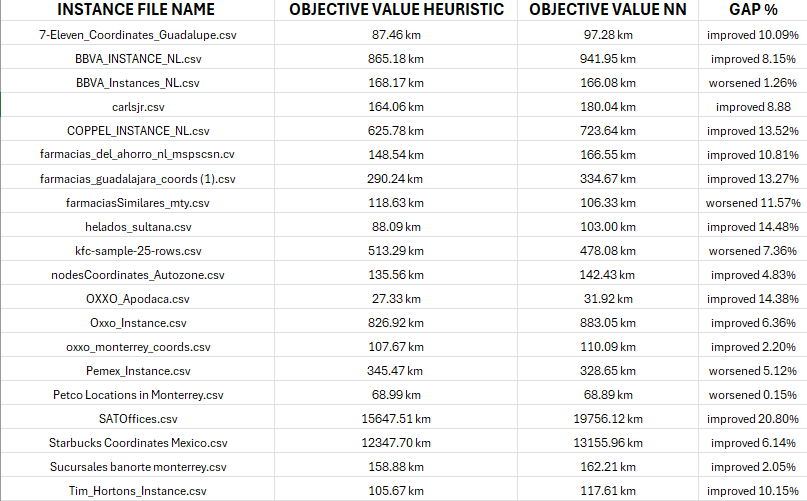

**Discussion:**

Our tests yielded positive results: In 9 of the 20 instances of the TSP where it was applied, there was an improvement of over 10% compared to the NN, improving in all but 4 cases, where it worsened (negligibly so in one of them at .15%).
The highest improvement is in the SAT offices instance with 20.80% in distance reduction, which is also notable for being the largest (geographically) instance tested overall; on the other hand, the worst case is the Farmacias Similares pharmacies, where the distance increased by 11.57%, in this case the instance was not especially large or small geographically in comparison to the others overall.

Regarding computation time, most instances took between 6 to 14 seconds to compute, depending as one might expect on the complexity of the instance and the amount of nodes. Two notable exceptions are the BBVA bank instance and the OXXO instance, as due to the their complexity they took around 4 minutes to compute.
It could be noted that the instances where the heuristic implemented did not improve the solution tended to be smaller than the others, so we could perhaps say that due to the smaller size the nodes and routes could result in the NN being more effective simply due to the way the instance is structured, though it becomes less likely that the instance happens to be structured favorably to NN as its size grows.
Overall, we can conclude that the implemented heuristic reduces the distance traveled in comparison to the nearest neighbor heuristic, as it proved more effective in 15 out of 20 cases.

## 9. General Conclusions

Summarize the main findings, lessons learned, and possible future work.

In general, this activity was a valuable learning experience for our team. First of all, this was our first time using the Python programming language as a team, and it has introduced us to the usage of the many extensive libraries that it offers; after all, although we may have had used it in some ways before for subjects of the previous semester, none of it was comparable to what we have done now. Given that during the rest of this course, and potentially our careers we will continue to use Python, it will certainly prove valuable to have acquired this experience.

This was also our first time applying a constructive heuristic to solve not just a particular instance of a combinatorial optimization problem, but rather making a heuristic that can be applied to any instance of the Travelling Salesman Problem that consists of real locational data. In this sense, it is an especially valuable lesson in that we have started to apply solutions for new real world cases rather than simply using hypothetical made up data, as we had until now. Additionally, we also began to compare the restults between two different heuristics, with one as a baseline and the objective to make a heuristic with better results. Since the field of combinational optimization relies heavily on heuristic methods to solve problems, we shall certainly continue to do this in the future.

And what's next? For possible future work, it is true that in the real world routing problems are not quite as simple as the basic TSP, featuring things such as the amount of drivers, scheduled deliveries, priority of certain clients over others, the amount of time available in each shift, multiple depots, etc.; all of these are used in the real world by companies in their optimization instances, but to understand these it is essential to fully understand and apply solutions to the most basic form of them, the TSP. Naturally, we could possibly expand this heuristic to serve as a base for more complex combinatorial optimization problems, as well as apply them to real problems found in real businesses, and use the experience we have gained through this activity not just during the rest of the course but throughout our time in UANL and our careers as engineers as well.


## 10. Consultation References

Hoffman, K. L., & Padberg, M. (2001). Traveling salesman problem. Encyclopedia of Operations Research and Management Science (pp. 849–853). Springer US.